In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/drive/MyDrive/EMNIST dataset/emnist_source_files"

In [ ]:
#Installing Dependencies
!pip install idx2numpy tensorflow numpy matplotlib emnist

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import time
import idx2numpy
import os

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=825f0676f71b8382aedb50f2395859b1e332f9c8a3a94dec69c691f7e3539fbc
  Stored in directory: /root/.cache/pip/wheels/87/e5/e7/70fc742b3645ddf9d392f766feccbcc95cb3a3c806f8588af0
Successfully built idx2numpy


In [ ]:
#Checking Dataset
def check_dataset():
    print("=== Checking Dataset ===")
    try:
        files = {
            "train_images": os.path.join(DATA_DIR, "emnist-letters-train-images-idx3-ubyte"),
            "train_labels": os.path.join(DATA_DIR, "emnist-letters-train-labels-idx1-ubyte"),
            "test_images": os.path.join(DATA_DIR, "emnist-letters-test-images-idx3-ubyte"),
            "test_labels": os.path.join(DATA_DIR, "emnist-letters-test-labels-idx1-ubyte")
        }

        # Check for missing files
        missing = [name for name, path in files.items() if not os.path.exists(path)]
        if missing:
            raise FileNotFoundError(f"Missing files: {', '.join(missing)}. Ensure all .idx files are in {DATA_DIR}")

        x_train = idx2numpy.convert_from_file(files["train_images"])
        y_train = idx2numpy.convert_from_file(files["train_labels"])
        x_test = idx2numpy.convert_from_file(files["test_images"])
        y_test = idx2numpy.convert_from_file(files["test_labels"])

        print("EMNIST 'letters' dataset is accessible.")
        print(f"Training samples: {len(x_train)}, Test samples: {len(x_test)}")
        print(f"Image shape: {x_train[0].shape}, Label range: {y_train.min()}–{y_train.max()}")
    except Exception as e:
        print(f"Error accessing EMNIST dataset: {e}")
check_dataset()

=== Checking Dataset ===
EMNIST 'letters' dataset is accessible.
Training samples: 124800, Test samples: 20800
Image shape: (28, 28), Label range: 1–26


In [ ]:
#Loading dataset
def load_dataset():
    print("\n=== Loading Dataset ===")
    files = {
        "train_images": os.path.join(DATA_DIR, "emnist-letters-train-images-idx3-ubyte"),
        "train_labels": os.path.join(DATA_DIR, "emnist-letters-train-labels-idx1-ubyte"),
        "test_images": os.path.join(DATA_DIR, "emnist-letters-test-images-idx3-ubyte"),
        "test_labels": os.path.join(DATA_DIR, "emnist-letters-test-labels-idx1-ubyte")
    }

    x_train = idx2numpy.convert_from_file(files["train_images"])
    y_train = idx2numpy.convert_from_file(files["train_labels"])
    x_test = idx2numpy.convert_from_file(files["test_images"])
    y_test = idx2numpy.convert_from_file(files["test_labels"])

    y_train = y_train - 1  # Adjust labels from 1–26 to 0–25 for zero-based indexing
    y_test = y_test - 1
    print(f"Loaded training data: {x_train.shape}, labels: {y_train.shape}")
    print(f"Loaded test data: {x_test.shape}, labels: {y_test.shape}")
    return x_train, y_train, x_test, y_test
x_train, y_train, x_test, y_test = load_dataset()



=== Loading Dataset ===
Loaded training data: (124800, 28, 28), labels: (124800,)
Loaded test data: (20800, 28, 28), labels: (20800,)


In [ ]:
#Feature extraction
def extract_features(x_train, x_test):
    print("\n== Feature Extraction ===")
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    print(f"Normalized training data shape: {x_train.shape}")
    print(f"Normalized test data shape: {x_test.shape}")
    print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")
    return x_train, x_test
x_train, x_test = extract_features(x_train, x_test)


== Feature Extraction ===
Normalized training data shape: (124800, 28, 28, 1)
Normalized test data shape: (20800, 28, 28, 1)
Pixel value range: [0.0, 1.0]


In [ ]:
#Splitting the  data
def split_data(y_train, y_test):
    print("\n===  Splitting Data ===")
    y_train = tf.keras.utils.to_categorical(y_train, 26)
    y_test = tf.keras.utils.to_categorical(y_test, 26)
    print(f"One-hot encoded training labels shape: {y_train.shape}")
    print(f"One-hot encoded test labels shape: {y_test.shape}")
    print(f"Sample label (first training sample): {y_train[0]}")
    return y_train, y_test
y_train, y_test = split_data(y_train, y_test)



===  Splitting Data ===
One-hot encoded training labels shape: (124800, 26)
One-hot encoded test labels shape: (20800, 26)
Sample label (first training sample): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0.]


In [ ]:
#Training the  model (with GPU check)
def train_model(x_train, y_train, x_test, y_test):
    print("\n=== Training Model ===")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"Using GPU: {gpus[0].name}")
        tf.config.experimental.set_memory_growth(gpus[0], True)
    else:
        print("Using CPU.")

    # Building  CNN  Model
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(26, activation='softmax')  # 26 classes for A–Z
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    # Training with larger dataset
    start_time = time.time()
    history = model.fit(x_train, y_train, epochs=3, batch_size=128,
                        validation_data=(x_test, y_test), verbose=1)
    end_time = time.time()
    print(f"Training time: {end_time - start_time:.2f} seconds")
    return model, history
model, history = train_model(x_train, y_train, x_test, y_test)


=== Training Model ===
Using GPU: /physical_device:GPU:0


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,954 (519.35 KB)

 Trainable params: 132,954 (519.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
975/975 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.5856 - loss: 1.3906 - val_accuracy: 0.9022 - val_loss: 0.3028
Epoch 2/3
975/975 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8741 - loss: 0.3983 - val_accuracy: 0.9219 - val_loss: 0.2411
Epoch 3/3
975/975 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8995 - loss: 0.3164 - val_accuracy: 0.9268 - val_loss: 0.2162
Training time: 24.80 seconds


In [ ]:
#Evaluating the cnn model
def evaluate_model(model, x_test, y_test):
    print("\n=== Evaluating Model ===")
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    return test_loss, test_acc
test_loss, test_acc = evaluate_model(model, x_test, y_test)


=== Evaluating Model ===
Test Loss: 0.2162, Test Accuracy: 0.9268



=== Validating Model ===


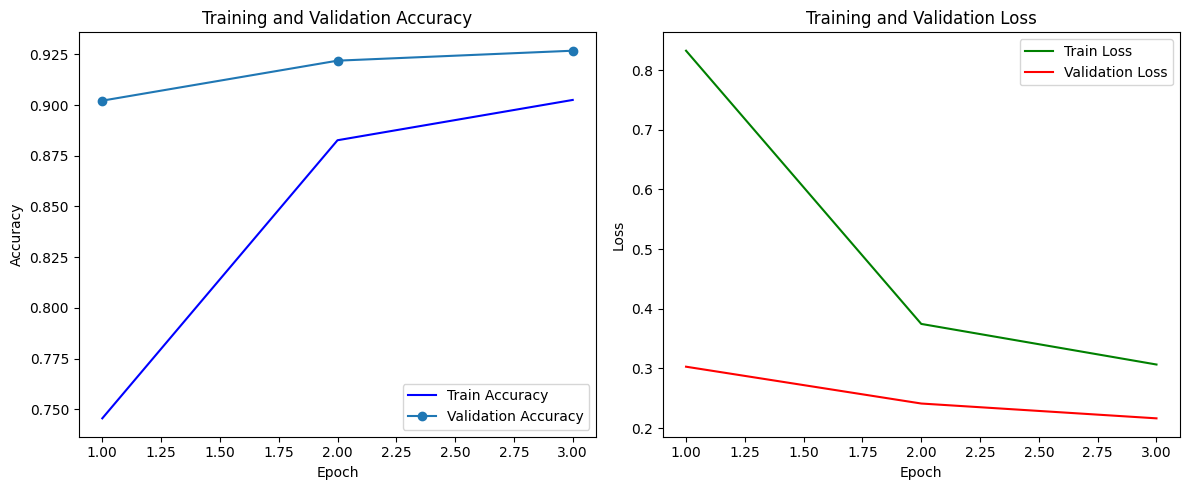

In [ ]:
#Validating the  model
def validate_model(history):
    print("\n=== Validating Model ===")
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], 'b-', label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], 'o-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], 'g-', label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
validate_model(history)


=== Cell 8: Testing with New Samples ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


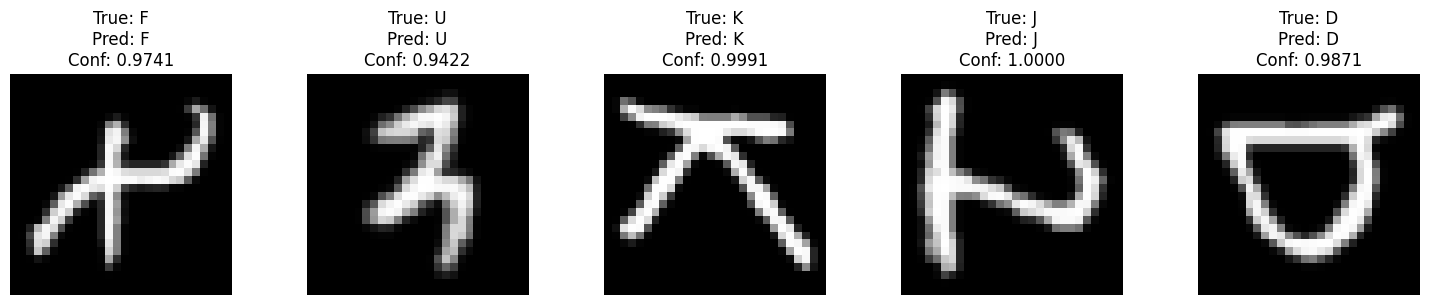

In [ ]:
#Testing with new sample
def test_new_sample(model, x_test, y_test, num_samples=5):
    print("\n=== Cell 8: Testing with New Samples ===")
    indices = np.random.choice(len(x_test), num_samples, replace=False)
    plt.figure(figsize=(15, 3))
    label_map = {i: chr(65 + i) for i in range(26)}
    for i, idx in enumerate(indices):
        sample_image = x_test[idx]
        sample_label = np.argmax(y_test[idx])
        prediction = model.predict(sample_image[np.newaxis, ...])
        predicted_label = np.argmax(prediction[0])
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(sample_image.squeeze(), cmap='gray')
        plt.title(f"True: {label_map[sample_label]}\nPred: {label_map[predicted_label]}\nConf: {prediction[0][predicted_label]:.4f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
test_new_sample(model, x_test, y_test)
